# Checkpoint 2: RQ Formation

## 1. Project Scope

**Dataset:** Elliptic++ Bitcoin Transactions dataset

A large transaction graph collected from the Bitcoin blockchain where each node represents a transaction and each edge represents Bitcoin flow between transactions. The dataset contains ~200K transactions, ~230K edges, 183 transaction features, 49 time steps, and labels (illicit, licit, unknown).

**EDA Findings:**
- The dataset is highly imbalanced, with illicit transactions forming a small minority
- The transaction graph is sparse and fragmented, with many small components and a few larger ones
- Degree distributions are heavily tailed, indicating the presence of hub-like transactions
- Analysis suggests that graph structure such as connectivity and neighborhood patterns may contain useful signals for identifying illicit activity
- Temporal analysis shows variation in transaction activity across time steps

**Course techniques:**

Graph mining (centrality, PageRank, community detection), classification, large-scale ML, anomaly detection methods, graph embeddings

**External techniques:**

Graph Neural Networks (GNNs)

## 2. Research Question Formation

### RQ1: Structural Graph Analysis (Course Technique)

Do illicit transactions occupy distinct structural positions in the transaction graph, and how do these patterns evolve over time?

**Data mining task type:** Graph mining with termporal analysis

**Relevent algorithms:**
- Degree centrality
- PageRank
- Betweenness centrality
- Community detection

**Evaluation criteria:**
- Distribution differences of centrality metrics between illicit and licit nodes
- Concentration of illicit transactions within communities
- Temporal trends in structural properties (e.g., degree, PageRank, illicit ratio over time)
- Interpretability of structural patterns

### RQ2: Anomaly Detection (Course Technique)

Can anomaly detection methods identify illicit transactions based on transaction features and graph-derived features?

**Data mining task type:** Anomaly detection

**Relevent algorithms:**
- Local Outlier Factor (LOF)
- Isolation Forest
- k-Nearest Neighbor (k-NN) anomaly detection

**Evaluation criteria:**
- Precision, recall, and F1 score for illicit transactions
- AUC (due to class imbalance)
- Comparison against a random baseline

### RQ3: Structural Graph Analysis (Course Technique)

Do Graph Neural Networks improve illicit transaction detection compared to classical approaches, and how does class imbalance handling affect their performance?

**Data mining task type:** Supervised learning on graphs

**Relevent algorithms:**
- External: Grpah Neural Networks
- Additional techniques: class weighting, focal loss

**Evaluation criteria:**
- F1 score (illicit class)
- ROC-AUC
- Comparison against anomaly detection methods and graph-feature-based models

## 3.Motivation and Feasibility

**Motivation:**
Initial EDA shows that the transaction graph is sparse, highly imbalanced, and exhibits heavy-tailed degree distributions. These findings suggest that graph structure and neighborhood relationships may provide useful signals for detecting illicit transactions.

**Non-triviality:**
Traditional feature-based methods may fail to capture relational dependencies between transactions. Graph mining and anomaly detection capture some structure, but may miss higher-order relationships, motivating the use of GNNs.

**Feasibility:**
The dataset provides node features, graph structure, and labels, making it suitable for both classical and graph-based methods. All proposed algorithms are implementable using standard Python libraries (e.g., NetworkX, scikit-learn, PyTorch Geometric).

**Risks:**
- Severe class imbalance may bias models toward the majority class
- Large graph size may increase computational cost for centrality and GNN training
- GNN performance may depend on hyperparameter tuning

**Mitigation strategies:**
- Use ROC-AUC and F1 as primary evaluation metrics
- Apply sampling or efficient implementations for graph computations

## 4. Methodological Planning
**Course algorithms:**
- Graph mining: centrality measures, PageRank, community detection
- Anomaly detection: LOF, Isolation Forest, k-NN

**External algorithms:**
- Graph Neural Networks (GCN or GraphSAGE)

**Evaluation plan:**
- Compare performance across methods using F1 (illicit class) and ROC-AUC
- Analyze interpretability of graph mining results
- Assess whether GNNs provide measurable improvement over classical approaches

**Baselines:**
- Random prediction baseline
- Feature-based anomaly detection
- Graph-feature-based classical models

**Initial feasibility checks:**
- Run centrality computations on a subset of the graph
- Test anomaly detection methods on labeled data
- Perform a small-scale GNN experiment to confirm training pipeline works

## Additional EDA to ensure method is feasible

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter, defaultdict

features_df = pd.read_csv("txs_features.csv")
classes_df = pd.read_csv("txs_classes.csv")
edges_df = pd.read_csv("txs_edgelist.csv")

print("Features shape:", features_df.shape)
display(features_df.head())
print("Classes shape:", classes_df.shape)
display(classes_df.head())
print("Edges shape:", edges_df.shape)
display(edges_df.head())



Features shape: (203769, 184)


,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680


Classes shape: (203769, 2)


,txId,class
0,3321,3
1,11108,3
2,51816,3
3,68869,2
4,89273,2


Edges shape: (234355, 2)


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [22]:
# fix column name
features_df = features_df.rename(columns={"Time step": "time_step"})

classes_df["class"] = classes_df["class"].astype(str).str.strip()
# map labels correctly
label_map = {
    "1": "illicit",
    "2": "licit",
    "3": "unknown"
}

# standardize labels
classes_df["label"] = classes_df["class"].map(label_map).fillna("unknown")

# create lookup dictionaries
label_dict = dict(zip(classes_df["txId"], classes_df["label"]))
time_dict = dict(zip(features_df["txId"], features_df["time_step"]))

# build graph
G = nx.from_pandas_edgelist(
    edges_df,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

print("Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")
print()
display(classes_df["label"].value_counts())



Graph: 203769 nodes, 234355 edges



,count
label,
unknown,157205
licit,42019
illicit,4545


### Class distribution

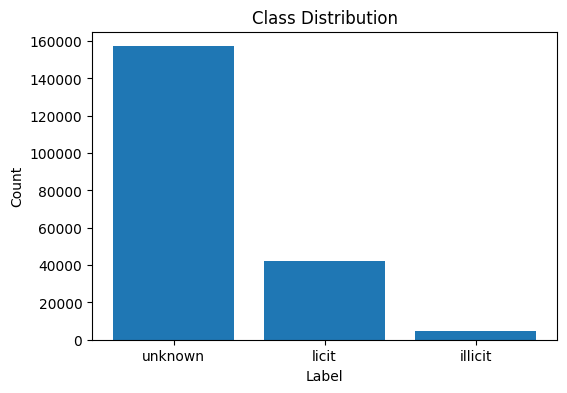

Counter({'unknown': 157205, 'licit': 42019, 'illicit': 4545})


In [18]:
label_counts = Counter(label_dict.values())

plt.figure(figsize=(6, 4))
plt.bar(list(label_counts.keys()), list(label_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(label_counts)

The dataset exhibits severe class imbalance. A large portion of nodes are unlabeled (“unknown”), and among labeled transactions, illicit cases are rare. This makes the detection problem challenging and motivates the use of anomaly detection methods and imbalance-aware learning techniques. Since illicit transactions are rare, they can naturally be treated as anomalies relative to normal (licit) behavior.

The imbalance necessitates techniques such as class weighting or focal loss to ensure that the model does not bias toward the majority class.


### Illicit ratio over time

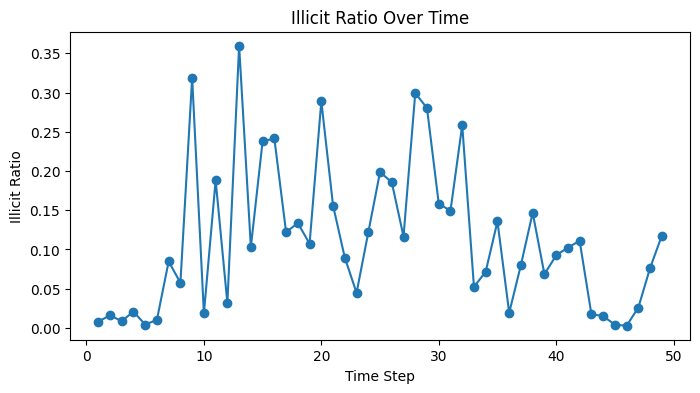

In [17]:
time_illicit = defaultdict(list)

for tx, t in time_dict.items():
    label = label_dict.get(tx, "unknown")
    if label in ["licit", "illicit"]:
        time_illicit[t].append(label == "illicit")

time_ratio = {t: sum(v) / len(v) for t, v in time_illicit.items() if len(v) > 0}

plt.figure(figsize=(8, 4))
plt.plot(sorted(time_ratio.keys()),
         [time_ratio[t] for t in sorted(time_ratio.keys())],
         marker="o")
plt.title("Illicit Ratio Over Time")
plt.xlabel("Time Step")
plt.ylabel("Illicit Ratio")
plt.show()

### Degree by label

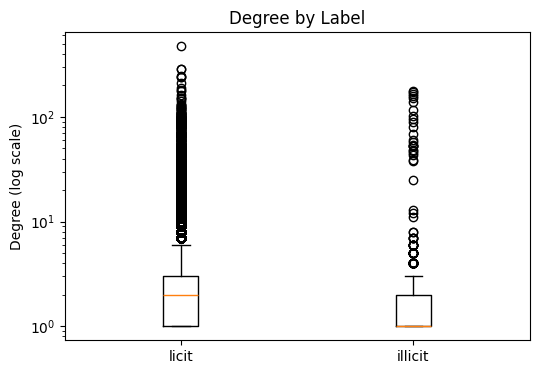

Avg licit degree: 3.095218829577096
Avg illicit degree: 2.0116611661166117


In [19]:
degree = dict(G.degree())

illicit_deg = []
licit_deg = []

for node, deg in degree.items():
    label = label_dict.get(node, "unknown")
    if label == "illicit":
        illicit_deg.append(deg)
    elif label == "licit":
        licit_deg.append(deg)

plt.figure(figsize=(6, 4))
plt.boxplot([licit_deg, illicit_deg], tick_labels=["licit", "illicit"])
plt.yscale("log")
plt.title("Degree by Label")
plt.ylabel("Degree (log scale)")
plt.show()

print("Avg licit degree:", np.mean(licit_deg))
print("Avg illicit degree:", np.mean(illicit_deg))

### PageRank by label

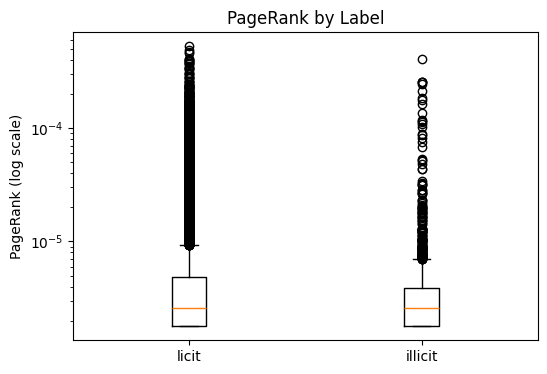

In [20]:
pagerank = nx.pagerank(G)

licit_pr = []
illicit_pr = []

for node, pr in pagerank.items():
    label = label_dict.get(node, "unknown")
    if label == "licit":
        licit_pr.append(pr)
    elif label == "illicit":
        illicit_pr.append(pr)

plt.figure(figsize=(6, 4))
plt.boxplot([licit_pr, illicit_pr], tick_labels=["licit", "illicit"])
plt.yscale("log")
plt.title("PageRank by Label")
plt.ylabel("PageRank (log scale)")
plt.show()

The PageRank distributions for licit and illicit transactions are largely overlapping, with similar medians and spread. This suggests that PageRank alone is not sufficient to clearly distinguish between the two classes.

PageRank indicates that both licit and illicit nodes can occupy important positions in the network, but it does not provide strong discriminatory power by itself. The lack of strong separation using a single global metric suggests that more complex models, such as GNNs, may be needed to capture local and multi-hop structural patterns.

### Homophily

In [24]:
same = 0
total = 0

for u, v in G.edges():
    lu = label_dict.get(u, "unknown")
    lv = label_dict.get(v, "unknown")

    if lu in ["licit", "illicit"] and lv in ["licit", "illicit"]:
        total += 1
        if lu == lv:
            same += 1

homophily = same / total if total > 0 else np.nan
print("Homophily:", homophily)

Homophily: 0.9536915683704674


Homophily measures the proprotion of edges that connect nodes with the same label. In this dataset, we see that homophily is 0.954, indicating that approximately 95.4% of edges between labeled nodes connect transactions of the same class.

High homophily storngly justifies the use of Graph Neural Networks. Since neighbords tend to have the same label, aggregating information from neighbors (as done in GNNs) is likely to improve prediction performance.


### Neighbor illicit ratio

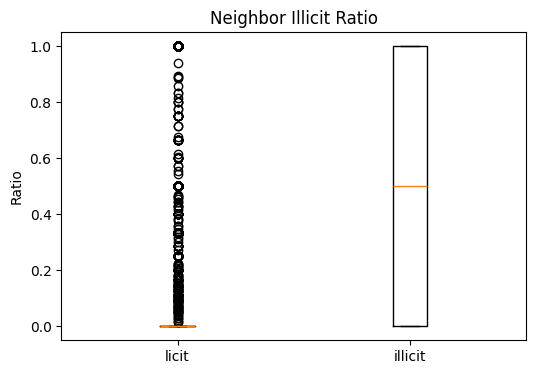

In [25]:
def neighbor_illicit_ratio(node):
    neighbors = set(G.predecessors(node)).union(set(G.successors(node)))
    neighbor_labels = [label_dict.get(n, "unknown") for n in neighbors]
    neighbor_labels = [lab for lab in neighbor_labels if lab in ["licit", "illicit"]]

    if len(neighbor_labels) == 0:
        return None

    return sum(lab == "illicit" for lab in neighbor_labels) / len(neighbor_labels)

ratios_licit = []
ratios_illicit = []

for node in G.nodes():
    r = neighbor_illicit_ratio(node)
    if r is None:
        continue

    label = label_dict.get(node, "unknown")
    if label == "licit":
        ratios_licit.append(r)
    elif label == "illicit":
        ratios_illicit.append(r)

plt.figure(figsize=(6, 4))
plt.boxplot([ratios_licit, ratios_illicit], tick_labels=["licit", "illicit"])
plt.title("Neighbor Illicit Ratio")
plt.ylabel("Ratio")
plt.show()

The results show a clear separation between licit and illicit nodes based on the proportion of illicit neighbors. Licit nodes have near-zero illicit neighbor ratios, while illicit nodes exhibit significantly higher values. This indicates strong local clustering of illicit activity in the graph.

This confirms that illicit transactions occupy distinct local regions in the graph, and neighbor-based features (such as illicit neighbor ratio) can serve as strong signals for identifyinf anomalies.

Since GNNs aggregate information from neighbors, this strong local signal suggests that GNNs can effectively leverage neighborhood structure to improve classificaiton.

## Additional initial method runs

### RQ2 - Anomaly detection
Tiny test with Isolation Forest

In [27]:
from sklearn.ensemble import IsolationForest

# use only labeled nodes
labeled_idx = [i for i, tx in enumerate(features_df["txId"])
               if label_dict.get(tx) in ["licit", "illicit"]]

X = features_df.drop(columns=["txId", "time_step"]).values
X_labeled = X[labeled_idx]

# map labels: illicit = 1 (anomaly), licit = 0
y_labeled = np.array([
    1 if label_dict[features_df["txId"][i]] == "illicit" else 0
    for i in labeled_idx
])

# fit model
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_labeled)

scores = -iso.decision_function(X_labeled)

print("Isolation Forest ran successfully")
print("Sample scores:", scores[:5])

Isolation Forest ran successfully
Sample scores: [-0.07896075  0.13208605 -0.09421945 -0.03792719 -0.04987418]


To verify the feasibility of anomaly detection methods, I performed an initial run of Isolation Forest on the node features of labeled transactions.

The model successfully trained and produced anomaly scores for each sample, indicating that it can distinguish between normal and anomalous patterns in the data.

The variation in scores suggests that the model is capturing meaningful differences between transactions, supporting the use of anomaly detection methods for RQ2.

### RQ3 - GNN feasibility
To check that graph conversion works and tensors can be built.

In [30]:
# !pip install torch-geometric

import torch
from torch_geometric.data import Data

# map txId to index
tx_to_idx = {tx: i for i, tx in enumerate(features_df["txId"])}

# edge index
edge_index = torch.tensor([
    [tx_to_idx[u] for u in edges_df["txId1"]],
    [tx_to_idx[v] for v in edges_df["txId2"]]
], dtype=torch.long)

# geatures
X = features_df.drop(columns=["txId", "time_step"]).values
x = torch.tensor(X, dtype=torch.float)

print("Graph tensor shapes:")
print("x:", x.shape)
print("edge_index:", edge_index.shape)

Graph tensor shapes:
x: torch.Size([203769, 182])
edge_index: torch.Size([2, 234355])


The dataset was successfully converted into GNN-compatible tensors, confirming feasibility of graph neural network methods.

# Resources

On my honor, I declare the following resources:

1. Collaborators:
 - None
---

2. Web Sources:
- https://github.com/git-disl/EllipticPlusPlus/tree/main/Transactions%20Dataset
- https://www.kaggle.com/datasets/ellipticco/elliptic-data-set/data
-https://pytorch-geometric.readthedocs.io/en/latest/modules/root.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
- https://pandas.pydata.org/docs/reference/frame.html#
- https://networkx.org/documentation/stable/reference/classes/digraph.html
https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html
- https://matplotlib.org/stable/api/index.html

---

3. AI Tools:
- ChatGPT: I used ChatGPT for assistance with debugging code and clarifying concepts such as GNNs and anomaly detection in order to determine RQ possibilities.

---

4. Citations
- Youssef Elmougy and Ling Liu. 2023. Demystifying Fraudulent Transactions and Illicit Nodes in the Bitcoin Network for Financial Forensics. In Proceedings of the 29th ACM SIGKDD Conference on Knowledge Discovery and Data Mining (KDD ’23), August 6–10, 2023, Long Beach, CA, USA. ACM, New York, NY, USA, 16 pages. https://doi.org/10.1145/3580305.3599803
- Y. Elmougy and O. Manzi, "Anomaly Detection on Bitcoin, Ethereum Networks Using GPU-accelerated Machine Learning Methods," 2021 31st International Conference on Computer Theory and Applications (ICCTA), Alexandria, Egypt, 2021, pp. 166-171, doi: 10.1109/ICCTA54562.2021.9916625. keywords: {Support vector machines;Bitcoin;Software;Blockchains;Fraud;Software reliability;Random forests;Cryptocurrency;Blockchain;Bitcoin;Ethereum;Anomaly Detection;Fraud;Machine Learning;GPU-acceleration;SVM;Random Forest;Logistic Regression},



